In [1]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## SALBP-2 model formulation
-----------------------------------------

When it comes to the "Simple Assembly Line Balancing Problem no. 2" there is a number of N operations with precedence relations to be performed on a fixed number of M stations. 
The operations are to be distributed among the stations in such a way that the cycle time is minimized. A simple result is illustrated in this precedence graph including station assignments.

<img src="pics/header.png" alt="Precedence graph" width="700">

### Objective function:

 0) The goal of the model is to minimize the cycle time:   $ \hspace{31mm} min \quad z = C $

### Constraints:

1) Assignment of  every  operation  only once: $\hspace{45mm} \sum_{k=1}^MS_{ik}=1  \hspace{39mm} \forall i=1,...,N $ 

2) Complying with the precedence relations: $\hspace{45mm} \sum_{k=1}^MS_{ik}\cdot k \leq \sum_{k=1}^MS_{jk}\cdot k \hspace{13mm} 
\forall(i,j) \in P$

3) Complying with the cycle time: $\hspace{63mm} \sum_{i=1}^NS_{ik} \cdot t_i \leq C \hspace{33mm} \forall k=1,...,M $

4) Binary decision variable: $\hspace{74mm} S_{ik} \in \{0,1\} \hspace{41mm} \forall i=1,...,N;k=1,...,M $

5) Non-negativity constraint: $\hspace{72mm} C \geq0$

---

#### Indices and sets
$i,j\in(1,..,N) \hspace{15mm}$  operations                      

$k\in(1,..,M) \hspace{17mm}$ stations                         

$(i,j)\in P \hspace{26mm}$ set of precedence relations     

#### Parameters
$t_i \hspace{40mm}$  Processing time of operation i 

#### Decision variables
$S_{ik} \hspace{38mm}$  Binary variable             

$C \hspace{41mm}$  Cycle time 

------------------------------------------------------------

### Create the model.
---

Initialize the model m with Gurobi as optimizer.

In [2]:
# Model
m = gp.Model("MILP")


# Surpress Output
m.setParam("OutputFlag", 0)
m.setParam("MIPgap", 0)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2726523
Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de


### Sets and parameters
---

In [3]:
Operations = [1,2,3,4,5,6,7,8,9]
Stations = [1,2,3,4,5,6]
Variants = [1,2,3]
quantities = [10, 20, 10]

N = len(Operations)
M = len(Stations)

PrecRelations = [ [1, 3], [1, 4], [2, 4], [2, 7], [3, 5], [4, 6], [7, 6], [7, 9], [5, 8], [6, 8], [6, 9] ]
t = [[5.5, 7.4, 1.3, 9, 2.6, 4.6, 8, 4.5, 3], [3.5, 6.4, 3.3, 8, 4.6, 4.6, 7, 6.5, 4], [2.5, 9.4, 2.3, 9, 3.6, 2.6, 5, 2.5, 1]]

N_switch = {(1,2):1, (2,3):1, (1,3):0, (2,1):0, (3,1):0, (3,2):0}
Setup_times = [2, 3, 3.2, 2.7, 2, 3]

### Decision variables
---

In [4]:
#The binary decision variable $S_{ik}$ is 1 if an operation i is assigned to station k, otherwise 0.
S = m.addVars(N, M, vtype=GRB.BINARY, name="S") 
# Non-negativity constraint:  The cycle time C can't be negative.
Cmax = m.addVar(lb=0, name="Cmax")
# Auxiliary variable to break symmetry:  Prefer assignment to lower station number in case of multiple solutions
symBreak = m.addVar(lb=0, name="symBreak");

### Objective function 
---

In [5]:
m.setObjective(Cmax + symBreak, GRB.MINIMIZE)

### Constraints
---


In [6]:
# Assign every operation only once
m.addConstrs((quicksum(S[i, k] for k in range(M)) == 1 for i in range(N)), name="allOperCon")

# Complying the precedence relations
m.addConstrs((quicksum(S[i, k]*k for k in range(M)) <= quicksum(S[j, k]*k for k in range(M))
              for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="precRelCon")

#Complying the cycle time
#m.addConstrs((quicksum(S[i, k]*t[i] for i in range(N)) <= C for k in range(M)), name="cycleTimeCon")

# Symmetry breaking constraint
m.addConstr(symBreak >= quicksum(S[i, k]*k*(0.1**(i+1)) for k in range(M) for i in range(N)), name="symBreakCon")

# makespan per station (batch over all cars + setup)
m.addConstrs((
    quicksum(
        S[i, k] * quicksum(quantities[v-1] * t[v-1][i] for v in Variants)
        for i in range(N)
    ) + Setup_times[k] <= Cmax
    for k in range(M)
), name="makespan_station")


{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>,
 5: <gurobi.Constr *Awaiting Model Update*>}

### Solve and display results
---

In [7]:
m
# Solve
m.optimize()

### Get the results displayed.

Print out the objective value C as well as the termination status and the primal status.

In [16]:
# Print results
if m.status == GRB.OPTIMAL:
    print("Objective value: ", m.objVal)
    print("Makespan Cmax: ", Cmax.x)
    print("Solution:")
    for i in range(N):
        for k in range(M):
            if S[i, k].x > 0.5:
                print("Operation ", i+1, " is assigned to station ", k+1)
else:
    print("No solution found")

Objective value:  342.710344255
Makespan Cmax:  342.7
Solution:
Operation  1  is assigned to station  1
Operation  2  is assigned to station  2
Operation  3  is assigned to station  1
Operation  4  is assigned to station  4
Operation  5  is assigned to station  5
Operation  6  is assigned to station  5
Operation  7  is assigned to station  3
Operation  8  is assigned to station  6
Operation  9  is assigned to station  6


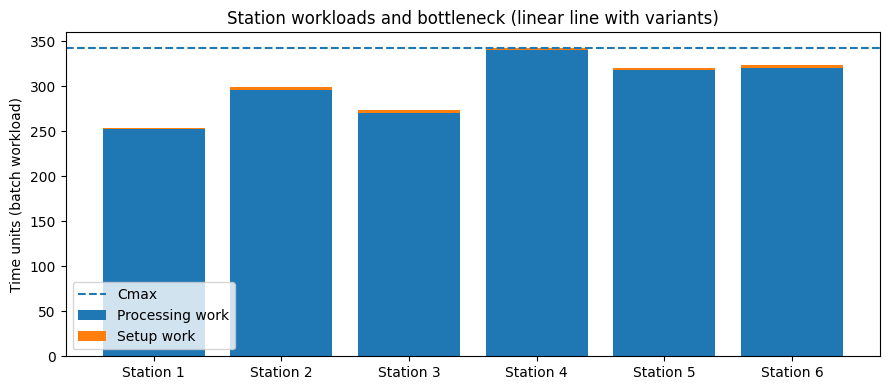

Bottleneck station: 4


In [13]:
import matplotlib.pyplot as plt
from gurobipy import GRB

# Extract assignment
assign = {i: next(k for k in range(M) if S[i,k].X > 0.5) for i in range(N)}

# Processing work per station
proc = [0.0]*M
for i in range(N):
    k = assign[i]
    proc[i_k := k] += sum(quantities[v-1] * t[v-1][i] for v in Variants)

setup = [Setup_times[k] for k in range(M)]
total = [proc[k] + setup[k] for k in range(M)]
slack = [Cmax.X - total[k] for k in range(M)]

# Plot
fig, ax = plt.subplots(figsize=(9,4))
x = list(range(M))

ax.bar(x, proc, label="Processing work")
ax.bar(x, setup, bottom=proc, label="Setup work")
ax.axhline(Cmax.X, linestyle="--", label="Cmax")

ax.set_xticks(x)
ax.set_xticklabels([f"Station {k+1}" for k in x])
ax.set_ylabel("Time units (batch workload)")
ax.set_title("Station workloads and bottleneck (linear line with variants)")
ax.legend()
plt.tight_layout()
plt.show()

print("Bottleneck station:", 1 + max(range(M), key=lambda k: total[k]))


TypeError: unsupported operand type(s) for /: 'list' and 'int'

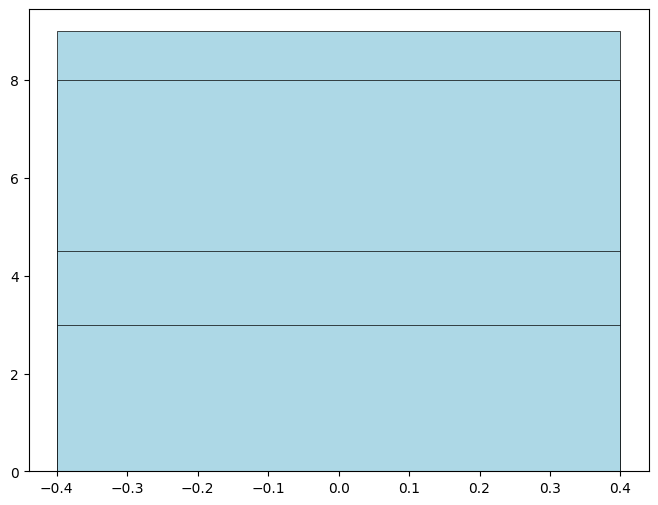

In [10]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(8,6))

# Iterate through each station
for k in range(M):
    bottom = 0
    for i in range(N):
        if S[i,k].X ==1:
            ax.bar(k, t[i], bottom=bottom, color='lightblue', edgecolor='black', linewidth=0.5)
            ax.text(k, bottom + t[i]/2, str(i+1), va='center', ha='center')
            bottom += t[i]
    if (C.X - bottom) >= 0.5:
        ax.annotate('',xy=(k, C.X),xytext=(k, bottom), arrowprops=dict(arrowstyle='<->', lw=1))
    if (C.X - bottom)!=0:
        ax.text(k+0.05, (bottom + (C.X - bottom-0.3)/2), f"loss: {round(C.X - bottom, 2)}", fontsize=10, color="red")

ax.axhline(C.X, linestyle = "--", color="red", label = "cycle time")
# Set x ticks and labels
ax.set_xticks(range(M))
ax.set_xticklabels([m+1 for m in range(M)])

# Set labels
ax.set_ylabel('Operation time')
ax.set_xlabel('Station')
ax.set_title('Operation time per Station')

fig.legend(loc="lower right")

# Show the plot
plt.show()